In [1]:
import pandas as pd
df = pd.read_csv('National_Health_and_Aging_Trends_Study__NHATS____Vision_and_Eye_Health_Surveillance_System__VEHSS_.csv')

In [ ]:
## filtruje tylko ostrość wzroku do dali
df_vd = df[df["Question"] == "Presenting visual acuity"]
##filtruje tylko cukrzycę
df_vd = df_vd[df_vd["RiskFactor"] == "Diabetes"]
## Sprzątanie danych
###usuwanie wierszy gdzie wystepuja pustki
df_vd = df_vd.dropna(subset=["Data_Value", "RiskFactor","RiskFactorResponse", "Response"])
### usunięcie odpowiedzi "Missing presenting aquity"
df_vd = df_vd[df_vd["Response"] != "Missing presenting acuity"]


print(df_vd.head(5))

    YearStart  YearEnd StateAbbr LocationAbbr LocationDesc GeographicLevel  \
44       2022     2022        US           US     National        National   
48       2022     2022        US           US     National        National   
49       2022     2022        US           US     National        National   
68       2022     2022        US           US     National        National   
89       2022     2022        US           US     National        National   

   DataSource            Topic                Category  \
44      NHATS  Visual Function  Measured Visual Acuity   
48      NHATS  Visual Function  Measured Visual Acuity   
49      NHATS  Visual Function  Measured Visual Acuity   
68      NHATS  Visual Function  Measured Visual Acuity   
89      NHATS  Visual Function  Measured Visual Acuity   

                    Question  ... ResponseID DataValueTypeID      AgeID SexID  \
44  Presenting visual acuity  ...     RVPMIL         CRDPREV    AGE8084  GALL   
48  Presenting visua

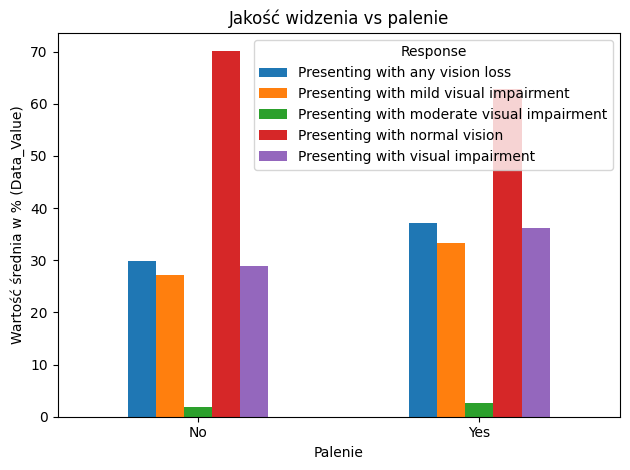

In [3]:
# tworzenie wykresu
import matplotlib.pyplot as plt
df_vd2 = df_vd
#PONIŻSZE MOŻNA ODHASZTAGOWAC, ALE NIE TRZEBA - WTEDY JEST CZYTELNIEJSZY WYKRES
#df_vd2 = df_vd[df_vd["Response"] == "Presenting with normal vision"]
# zliczanie kombinacji
counts = df_vd2.groupby(["RiskFactorResponse", "Response"])["Data_Value"].mean().unstack()

# wykres
counts.plot(kind="bar")

plt.xlabel("Palenie")
plt.ylabel("Wartość średnia w % (Data_Value)")
plt.title("Jakość widzenia vs palenie")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [7]:
#proba testu chi-kwadrat niezaleznosci
from scipy.stats import chi2_contingency
df_vd3 = df_vd
#ponizsze mozna ohasztagowac, ale nie trezba
df_vd3 = df_vd3[df_vd3["Response"] != "Presenting with any vision loss"]

# 1. Tworzenie tabeli krzyżowej (Crosstab)
# Jeśli Data_Value to procenty, sumujemy je, aby uzyskać proporcje dla grup
contingency_table = pd.crosstab(df_vd3["RiskFactorResponse"], 
                                df_vd3["Response"], 
                                values=df_vd3["Data_Value"], 
                                aggfunc="sum").fillna(0)

print("Tabela kontyngencji:")
print(contingency_table)

# 2. Wykonanie testu Chi-kwadrat
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nStatystyka Chi2: {chi2:.4f}")
print(f"Wartość p: {p:.4e}") # format naukowy, bo p może być bardzo małe
print(f"Stopnie swobody: {dof}")

Tabela kontyngencji:
Response            Presenting with mild visual impairment  \
RiskFactorResponse                                           
No                                                  542.16   
Yes                                                 599.62   

Response            Presenting with moderate visual impairment  \
RiskFactorResponse                                               
No                                                       32.17   
Yes                                                      32.16   

Response            Presenting with normal vision  \
RiskFactorResponse                                  
No                                        1402.11   
Yes                                       1131.05   

Response            Presenting with visual impairment  
RiskFactorResponse                                     
No                                             578.23  
Yes                                            652.13  

Statystyka Chi2: 32.4331
Wa